# HAB Predictor — Weighted Random Forest Baseline

Predict whether a given pier-week is a Harmful Algal Bloom (`pda > 0.1`).

- **Data:** `merged_hab_oisst_features.csv` (Jin's branch — already has lag features and Si:N ratio)
- **Target:** `isHarmful` (1 if `pda > 0.1`, else 0)
- **Class balance:** 195 harmful / 2883 quiet (~6.3% positive)
- **Primary metric:** **Recall** on the harmful class (per Katie — false alarms are cheap, missed blooms are not)
- **Imbalance handling:** `class_weight={0: 1, 1: 50}`
- **Split:** time-based (random splits leak the future)

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
)

## Load data

In [2]:
df = pd.read_csv('merged_hab_oisst_features.csv', parse_dates=['week_start'])
df = df.sort_values('week_start').reset_index(drop=True)
print('shape:', df.shape)
print('date range:', df['week_start'].min(), '->', df['week_start'].max())
print('stations:', df['station'].nunique())
df.head()

shape: (3078, 28)
date range: 2017-01-02 00:00:00 -> 2026-03-23 00:00:00
stations: 10


,week_start,station,sample_date,latitude,longitude,month,year,pda,temp,silicate,...,temp_lag1,temp_lag2,silicate_lag1,silicate_lag2,nitrate_lag1,nitrate_lag2,avg_chloro_lag1,avg_chloro_lag2,silicate_nitrate_ratio,isHarmful
0,2017-01-02,Cal Poly Pier,2017-01-02,35.170204,-120.740685,1,2017,0.0,10.0,14.5145,...,10.0,10.0,14.5145,14.5145,14.653976,14.653976,4.360,4.360,0.990482,0
1,2017-01-02,Newport Beach Pier,2017-01-02,33.606100,-117.931100,1,2017,0.0,14.2,4.2200,...,14.2,14.2,4.2200,4.2200,2.590000,2.590000,3.200,3.200,1.629344,0
2,2017-01-02,Santa Monica Pier,2017-01-02,34.008000,-118.499000,1,2017,0.0,15.8,6.2890,...,15.8,15.8,6.2890,6.2890,4.100000,4.100000,0.800,0.800,1.533902,0
3,2017-01-02,Stearns Wharf,2017-01-02,34.408043,-119.684850,1,2017,0.0,13.6,6.2290,...,13.6,13.6,6.2290,6.2290,3.498000,3.498000,0.847,0.847,1.780732,0
4,2017-01-02,Scripps Pier,2017-01-02,32.867000,-117.257000,1,2017,0.0,15.2,2.1000,...,15.2,15.2,2.1000,2.1000,0.540000,0.540000,0.890,0.890,3.888889,0


## Class balance

In [3]:
counts = df['isHarmful'].value_counts().sort_index()
print(counts)
print('positive rate:', counts.get(1, 0) / counts.sum())

isHarmful
0    2883
1     195
Name: count, dtype: int64
positive rate: 0.06335282651072124


In [4]:
per_station = (
    df.groupby('station')
      .agg(weeks=('isHarmful', 'size'), harmful_weeks=('isHarmful', 'sum'))
      .assign(harmful_rate=lambda d: d['harmful_weeks'] / d['weeks'])
      .sort_values('harmful_rate', ascending=False)
)
per_station

,weeks,harmful_weeks,harmful_rate
station,,,
Monterey Wharf,31,10,0.322581
Trinidad Pier,104,15,0.144231
Santa Cruz Wharf,445,51,0.114607
Humboldt,87,9,0.103448
Humboldt South Bay,100,8,0.080000
Stearns Wharf,451,24,0.053215
Newport Beach Pier,433,21,0.048499
Cal Poly Pier,473,21,0.044397
Scripps Pier,479,19,0.039666


## Features & target

In [5]:
FEATURES = [
    'temp', 'silicate', 'nitrate', 'avg_chloro',
    'temp_lag1', 'temp_lag2',
    'silicate_lag1', 'silicate_lag2',
    'nitrate_lag1', 'nitrate_lag2',
    'avg_chloro_lag1', 'avg_chloro_lag2',
    'silicate_nitrate_ratio',
    'sst_roll_14d', 'anom_roll_14d', 'sst_roc_3d',
    'warm_degree_days_14d', 'above_avg',
    'latitude', 'longitude', 'month',
]
TARGET = 'isHarmful'

model_df = df.dropna(subset=FEATURES + [TARGET]).copy()
print('rows after dropping NaN:', len(model_df), 'of', len(df))
print('positive rate after drop:', model_df[TARGET].mean())

rows after dropping NaN: 2426 of 3078
positive rate after drop: 0.07378400659521847


## Time-based train/test split

Train on everything before the cutoff, test on everything after. A random split would leak future weeks into training.

In [6]:
cutoff = model_df['week_start'].quantile(0.8)
train = model_df[model_df['week_start'] < cutoff]
test = model_df[model_df['week_start'] >= cutoff]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print('cutoff:', cutoff)
print('train size:', len(train), '| harmful:', int(y_train.sum()))
print('test size: ', len(test), '| harmful:', int(y_test.sum()))

cutoff: 2024-07-08 00:00:00
train size: 1936 | harmful: 106
test size:  490 | harmful: 73


## Weighted Random Forest — `class_weight={0: 1, 1: 50}`

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight={0: 1, 1: 50},
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['quiet', 'harmful'], digits=3))
print('confusion matrix [rows=true, cols=pred]:')
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob), 3))

              precision    recall  f1-score   support

       quiet      0.850     0.993     0.916       417
     harmful      0.000     0.000     0.000        73

    accuracy                          0.845       490
   macro avg      0.425     0.496     0.458       490
weighted avg      0.723     0.845     0.779       490

confusion matrix [rows=true, cols=pred]:
[[414   3]
 [ 73   0]]
ROC-AUC: 0.806


## Compare with `class_weight='balanced'`

In [8]:
rf_bal = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_bal.fit(X_train, y_train)
y_pred_bal = rf_bal.predict(X_test)
print(classification_report(y_test, y_pred_bal, target_names=['quiet', 'harmful'], digits=3))
print(confusion_matrix(y_test, y_pred_bal))

              precision    recall  f1-score   support

       quiet      0.851     0.998     0.918       417
     harmful      0.000     0.000     0.000        73

    accuracy                          0.849       490
   macro avg      0.425     0.499     0.459       490
weighted avg      0.724     0.849     0.782       490

[[416   1]
 [ 73   0]]


## Dummy baseline (always predict quiet)

Sanity check — the 97% accuracy trap Katie warned about.

In [9]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(classification_report(y_test, dummy.predict(X_test), target_names=['quiet', 'harmful'], digits=3, zero_division=0))

              precision    recall  f1-score   support

       quiet      0.851     1.000     0.920       417
     harmful      0.000     0.000     0.000        73

    accuracy                          0.851       490
   macro avg      0.426     0.500     0.460       490
weighted avg      0.724     0.851     0.783       490



## Feature importances

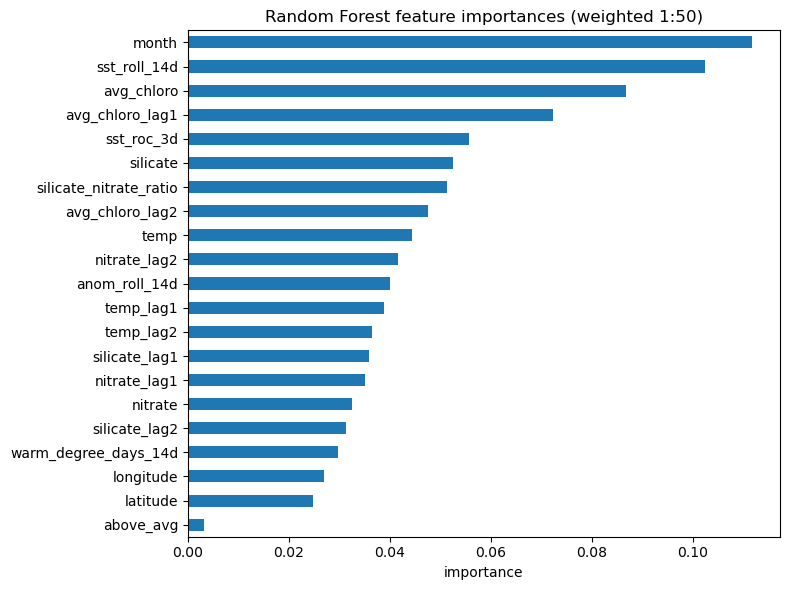

In [10]:
importances = (
    pd.Series(rf.feature_importances_, index=FEATURES)
      .sort_values(ascending=True)
)
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax)
ax.set_title('Random Forest feature importances (weighted 1:50)')
ax.set_xlabel('importance')
plt.tight_layout()
plt.show()

## Precision-Recall curve

Lets us pick a probability threshold that trades precision for more recall.

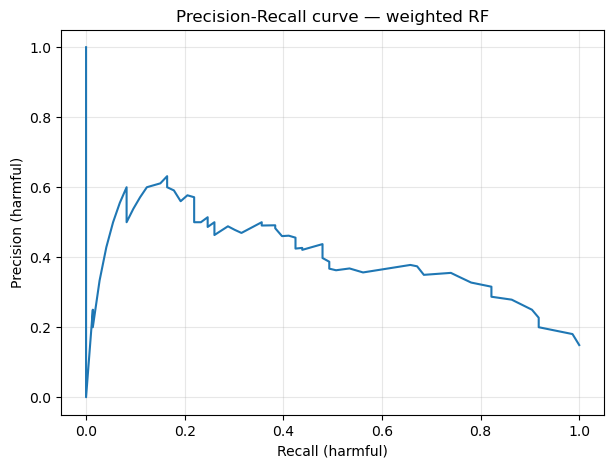

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision)
ax.set_xlabel('Recall (harmful)')
ax.set_ylabel('Precision (harmful)')
ax.set_title('Precision-Recall curve — weighted RF')
ax.grid(True, alpha=0.3)
plt.show()